In [ ]:
import json
import os
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.xgboost
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

/Users/ngocduy/PROJECTS/smart-banking-system/ml/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 2,701,957 rows | Fraud: 5,993 (0.222%)
Val:   33,583 rows | Fraud: 792 (2.358%)
Test:  34,098 rows | Fraud: 776 (2.276%)

Total columns: 28


## Model Training Plan

1. **Define feature set** — exclude identifiers, raw balances, and the target
2. **Handle class imbalance** — `scale_pos_weight = neg/pos` ratio
3. **Train XGBoost** with early stopping on validation set
4. **Evaluate** — AUC, PR-AUC, precision/recall at contract thresholds (0.5, 0.8)
5. **Threshold tuning** — find optimal threshold for F1 or business metric
6. **SHAP analysis** — global feature importance + per-decision explainability
7. **Baseline comparison** — our model vs PaySim's built-in `isFlaggedFraud` rule
8. **Export** — save as ONNX for deployment in `ml/app/`

### 1. Define Feature Set

We exclude:
- **Identifiers**: `nameOrig`, `nameDest` (strings, not features)
- **Raw balances**: `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest` (already encoded as errors + ratio)
- **Redundant**: `type` (encoded as `is_transfer`), `amount` (encoded as `amount_log` + `amount_zscore`)
- **Target**: `isFraud`
- **Baseline**: `isFlaggedFraud` (kept for comparison, not training)
- **Metadata**: `step` (encoded as time features)

In [2]:
# ============================================================
# 1. Define feature set
# ============================================================

DROP_COLS = [
    "nameOrig", "nameDest",           # identifiers
    "oldbalanceOrg", "newbalanceOrig", # encoded as orig_error + has_orig_error
    "oldbalanceDest", "newbalanceDest", # encoded as dest_error + has_dest_error
    "type",                            # encoded as is_transfer
    "amount",                          # encoded as amount_log + amount_zscore
    "step",                            # encoded as time features
    "isFraud",                         # target
    "isFlaggedFraud",                  # baseline (not a feature)
]

feature_cols = [c for c in train.columns if c not in DROP_COLS]

X_train = train[feature_cols]
y_train = train["isFraud"]
X_val = val[feature_cols]
y_val = val["isFraud"]
X_test = test[feature_cols]
y_test = test["isFraud"]

print(f"Feature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\nX_train: {X_train.shape} | y_train fraud: {y_train.sum():,}")
print(f"X_val:   {X_val.shape} | y_val fraud:   {y_val.sum():,}")
print(f"X_test:  {X_test.shape} | y_test fraud:  {y_test.sum():,}")

Feature columns (17):
   1. orig_error
   2. dest_error
   3. has_orig_error
   4. has_dest_error
   5. is_transfer
   6. amount_log
   7. balance_emptying_ratio
   8. sin_hour
   9. cos_hour
  10. sin_dow
  11. cos_dow
  12. velocity_1h
  13. velocity_24h
  14. velocity_3d
  15. amount_zscore
  16. new_recipient_flag
  17. time_since_last_txn

X_train: (2701957, 17) | y_train fraud: 5,993
X_val:   (33583, 17) | y_val fraud:   792
X_test:  (34098, 17) | y_test fraud:  776


### 2. Handle Class Imbalance

PaySim fraud rate is ~0.13%. Without adjustment, the model predicts "not fraud" for everything and gets 99.87% accuracy — useless.

XGBoost's `scale_pos_weight` reweights the positive class:

$$\text{scale\_pos\_weight} = \frac{\text{count(neg)}}{\text{count(pos)}}$$

This makes each fraud example count as much as ~770 legitimate examples during training.

In [3]:
# ============================================================
# 2. Compute scale_pos_weight
# ============================================================

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Negative (legit): {neg_count:,}")
print(f"Positive (fraud): {pos_count:,}")
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

Negative (legit): 2,695,964
Positive (fraud): 5,993
scale_pos_weight: 449.9


### 3. Train XGBoost

Key hyperparameters:
- `scale_pos_weight` — handles imbalance
- `max_depth=6` — deep enough to capture interactions, shallow enough to avoid overfitting
- `learning_rate=0.05` — conservative, works well with early stopping
- `eval_metric='aucpr'` — PR-AUC is more informative than ROC-AUC for imbalanced data
- Early stopping after 50 rounds of no improvement on validation set

In [4]:
# ============================================================
# 3. Train XGBoost with early stopping
# ============================================================

model = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100,
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best validation AUC-PR: {model.best_score:.4f}")

[0]	validation_0-aucpr:0.99565	validation_1-aucpr:0.99880
[50]	validation_0-aucpr:0.99646	validation_1-aucpr:0.99788

Best iteration: 0
Best validation AUC-PR: 0.9988


### 4. Evaluate — Test Set

We evaluate on the held-out test set (last 10% of steps — never seen during training or early stopping).

=== Test Set Metrics ===
ROC-AUC:  1.0000
PR-AUC:   1.0000

Threshold 0.3: Precision=0.0228 | Recall=1.0000 | F1=0.0445 | Flagged=34,098 (100.00%)
Threshold 0.5: Precision=0.9974 | Recall=1.0000 | F1=0.9987 | Flagged=778 (2.28%)
Threshold 0.8: Precision=0.0000 | Recall=0.0000 | F1=0.0000 | Flagged=0 (0.00%)


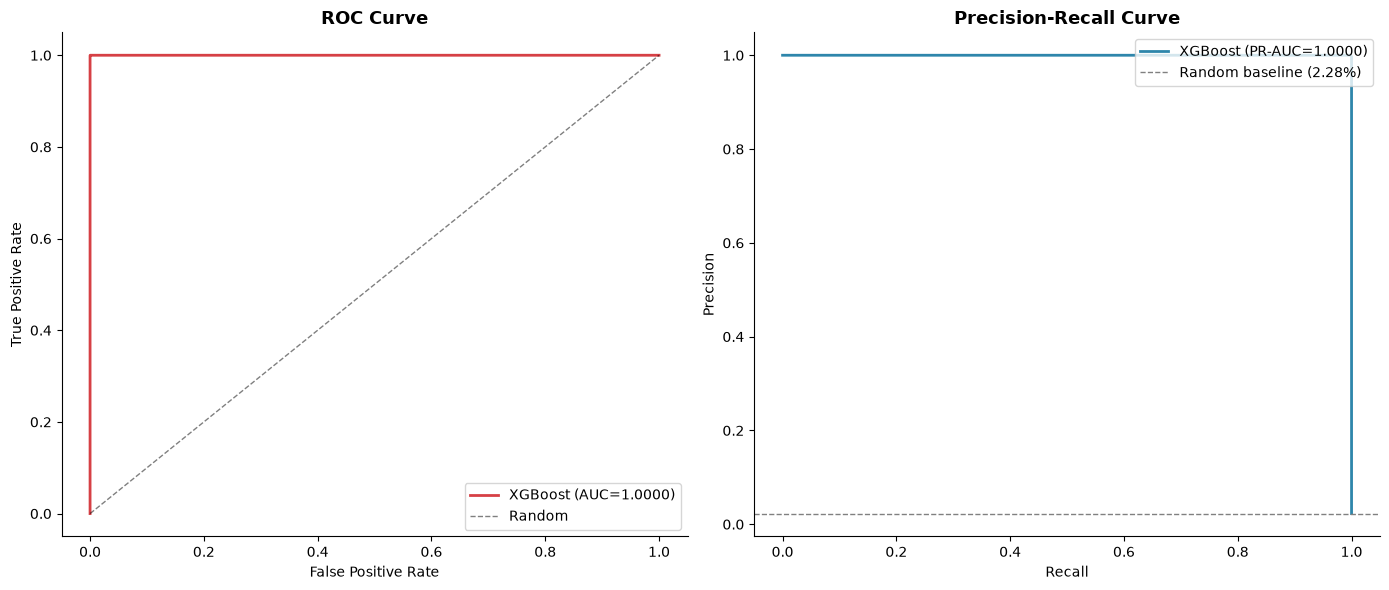

In [5]:
# ============================================================
# 4. Evaluate on test set
# ============================================================

y_prob = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

# --- ROC-AUC ---
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

# --- PR-AUC (more informative for imbalanced data) ---
pr_auc = average_precision_score(y_test, y_prob)
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_prob)

# --- Metrics at contract thresholds ---
def metrics_at_threshold(threshold: float):
    pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "flagged": pred.sum(),
        "flagged_pct": pred.mean() * 100,
    }

print("=== Test Set Metrics ===")
print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}")
print()
for t in [0.3, 0.5, 0.8]:
    m = metrics_at_threshold(t)
    print(f"Threshold {t}: Precision={m['precision']:.4f} | Recall={m['recall']:.4f} | F1={m['f1']:.4f} | Flagged={m['flagged']:,} ({m['flagged_pct']:.2f}%)")

# --- Visual: ROC + PR curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, color="#D64045", linewidth=2, label=f"XGBoost (AUC={roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
axes[0].set_title("ROC Curve", fontweight="bold", fontsize=13)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].plot(recall_curve, precision_curve, color="#2E86AB", linewidth=2, label=f"XGBoost (PR-AUC={pr_auc:.4f})")
axes[1].axhline(y=y_test.mean(), color="gray", linestyle="--", linewidth=1, label=f"Random baseline ({y_test.mean()*100:.2f}%)")
axes[1].set_title("Precision-Recall Curve", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")

sns.despine()
plt.tight_layout()
plt.show()

### 5. Threshold Tuning

The contract defines `SUSPICIOUS ≥ 0.5` and `BLOCKED ≥ 0.8`. But we should verify these are optimal for our model.

We find the threshold that maximizes F1 score on the validation set.

=== Threshold Tuning (Val Set) ===
 threshold  precision   recall       f1  flagged
      0.10   0.023583 1.000000 0.046080    33583
      0.15   0.023583 1.000000 0.046080    33583
      0.20   0.023583 1.000000 0.046080    33583
      0.25   0.023583 1.000000 0.046080    33583
      0.30   0.023583 1.000000 0.046080    33583
      0.35   0.023583 1.000000 0.046080    33583
      0.40   0.023583 1.000000 0.046080    33583
      0.45   0.023583 1.000000 0.046080    33583
      0.50   0.996217 0.997475 0.996845      793
      0.55   0.000000 0.000000 0.000000        0
      0.60   0.000000 0.000000 0.000000        0
      0.65   0.000000 0.000000 0.000000        0
      0.70   0.000000 0.000000 0.000000        0
      0.75   0.000000 0.000000 0.000000        0
      0.80   0.000000 0.000000 0.000000        0
      0.85   0.000000 0.000000 0.000000        0
      0.90   0.000000 0.000000 0.000000        0

Best F1 threshold: 0.50 (F1=0.9968, P=0.9962, R=0.9975)


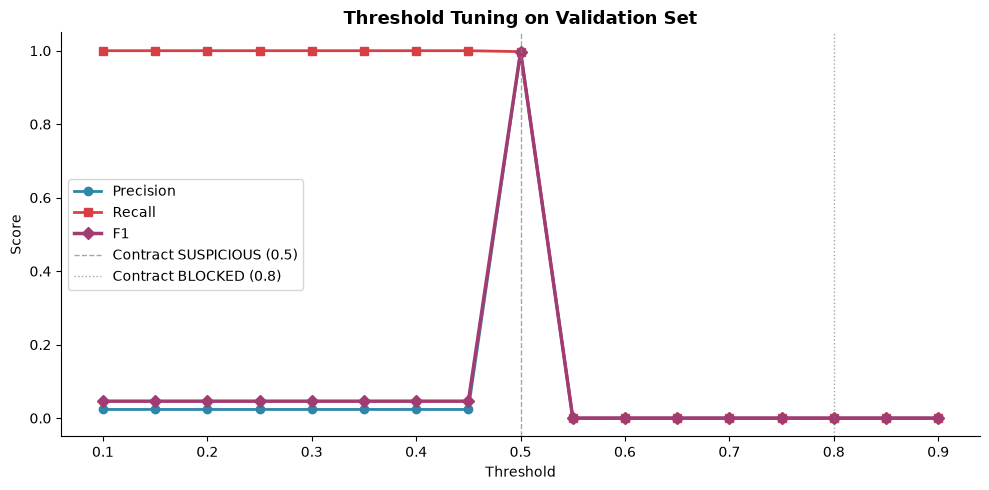

In [6]:
# ============================================================
# 5. Threshold tuning on validation set
# ============================================================

y_val_prob = model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.95, 0.05)
results = []
for t in thresholds:
    pred = (y_val_prob >= t).astype(int)
    results.append({
        "threshold": t,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred),
        "f1": f1_score(y_val, pred),
        "flagged": pred.sum(),
    })

tuning_df = pd.DataFrame(results)
best_f1 = tuning_df.loc[tuning_df["f1"].idxmax()]

print("=== Threshold Tuning (Val Set) ===")
print(tuning_df.to_string(index=False))
print(f"\nBest F1 threshold: {best_f1['threshold']:.2f} (F1={best_f1['f1']:.4f}, P={best_f1['precision']:.4f}, R={best_f1['recall']:.4f})")

# --- Visual ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tuning_df["threshold"], tuning_df["precision"], color="#2E86AB", linewidth=2, marker="o", label="Precision")
ax.plot(tuning_df["threshold"], tuning_df["recall"], color="#D64045", linewidth=2, marker="s", label="Recall")
ax.plot(tuning_df["threshold"], tuning_df["f1"], color="#A23B72", linewidth=2.5, marker="D", label="F1")
ax.axvline(x=0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Contract SUSPICIOUS (0.5)")
ax.axvline(x=0.8, color="gray", linestyle=":", linewidth=1, alpha=0.7, label="Contract BLOCKED (0.8)")
ax.set_title("Threshold Tuning on Validation Set", fontweight="bold", fontsize=13)
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

### 6. SHAP Analysis

Global feature importance + what drives individual predictions.

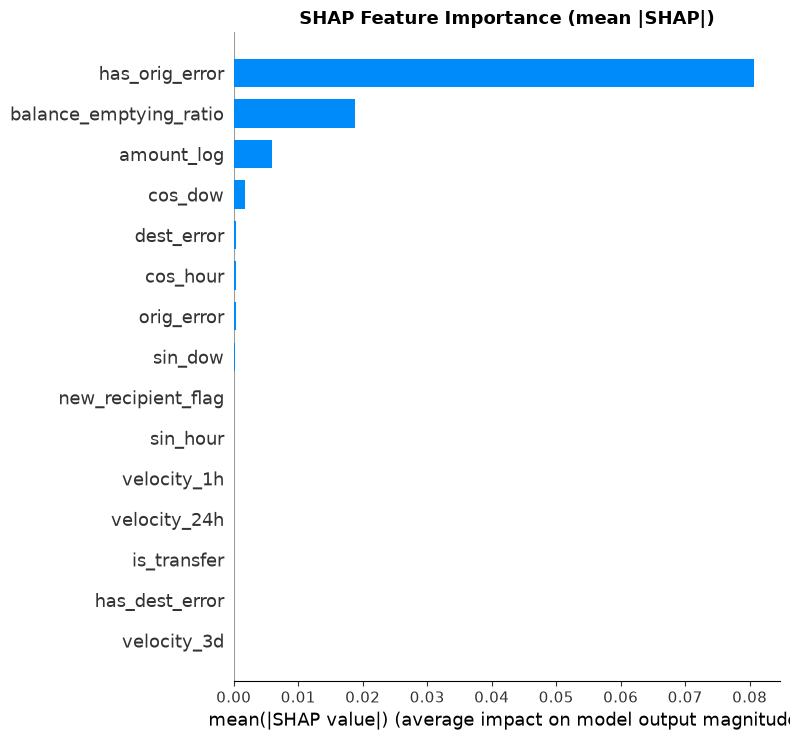

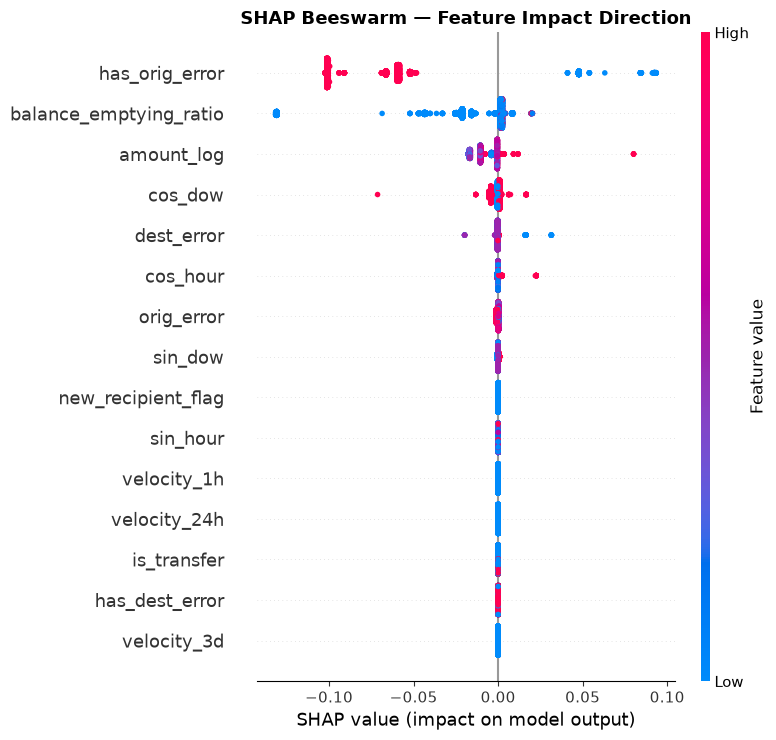

In [7]:
# ============================================================
# 6. SHAP — Global feature importance
# ============================================================

# Use TreeExplainer (fast, exact for XGBoost)
explainer = shap.TreeExplainer(model)

# Sample for SHAP (full test set is slow; 5000 rows is representative)
X_sample = X_test.sample(n=min(5000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# --- Summary bar plot ---
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=15)
plt.title("SHAP Feature Importance (mean |SHAP|)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

# --- Beeswarm (direction + magnitude) ---
shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
plt.title("SHAP Beeswarm — Feature Impact Direction", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

### 7. Baseline Comparison — isFlaggedFraud

PaySim's built-in rule: flag any TRANSFER > 200k. How does our model compare?

=== Baseline: isFlaggedFraud (amount > 200k TRANSFER) ===
Precision: 1.0000
Recall:    0.0026
F1:        0.0051
Flagged:   2 (0.0059%)

=== Our Model (threshold=0.5) ===
Precision: 0.9974
Recall:    1.0000
F1:        0.9987
Flagged:   778 (2.2817%)


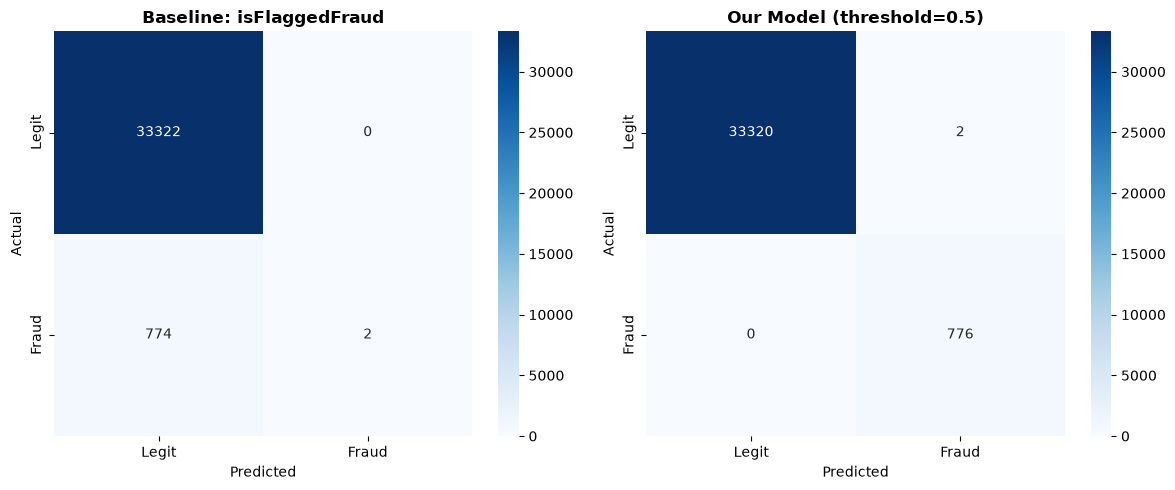

In [8]:
# ============================================================
# 7. Baseline: isFlaggedFraud vs our model
# ============================================================

baseline_pred = test["isFlaggedFraud"]

print("=== Baseline: isFlaggedFraud (amount > 200k TRANSFER) ===")
print(f"Precision: {precision_score(y_test, baseline_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, baseline_pred):.4f}")
print(f"F1:        {f1_score(y_test, baseline_pred):.4f}")
print(f"Flagged:   {baseline_pred.sum():,} ({baseline_pred.mean()*100:.4f}%)")

print(f"\n=== Our Model (threshold=0.5) ===")
print(f"Precision: {precision_score(y_test, y_pred_default, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_default):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_default):.4f}")
print(f"Flagged:   {y_pred_default.sum():,} ({y_pred_default.mean()*100:.4f}%)")

# --- Confusion matrices side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in [
    (axes[0], baseline_pred, "Baseline: isFlaggedFraud"),
    (axes[1], y_pred_default, "Our Model (threshold=0.5)"),
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

### 8. Export Model for Deployment

Save as ONNX for `ml/app/` inference service. Also save the feature column list so the serving code knows which features to compute.

In [9]:
# ============================================================
# 8. Export ONNX model + feature metadata
# ============================================================

import onnxmltools
from onnxmltools.convert import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# onnxmltools requires feature names in f0, f1, ... format.
# We rename the model's internal feature names, convert, then save the mapping.
f_names = [f"f{i}" for i in range(len(feature_cols))]
name_map = dict(zip(f_names, feature_cols))  # f0 → has_orig_error, etc.

model.get_booster().feature_names = f_names

# Convert to ONNX — single input tensor of shape [batch, num_features]
initial_type = [("float_input", FloatTensorType([None, len(feature_cols)]))]
onnx_model = convert_xgboost(
    model,
    initial_types=initial_type,
    target_opset=15,
)

onnx_path = MODELS_DIR / "fraud_model.onnx"
onnxmltools.utils.save_model(onnx_model, str(onnx_path))
print(f"✅ ONNX model saved: {onnx_path} ({onnx_path.stat().st_size / 1024:.1f} KB)")

# Save feature metadata for serving
feature_meta = {
    "model_version": "xgboost-v1.0.0",
    "feature_columns": feature_cols,
    "onnx_input_name": "float_input",
    "onnx_feature_names": f_names,
    "feature_name_map": name_map,
    "num_features": len(feature_cols),
    "scale_pos_weight": scale_pos_weight,
    "best_iteration": int(model.best_iteration),
    "test_roc_auc": roc_auc,
    "test_pr_auc": pr_auc,
    "threshold_suspicious": 0.5,
    "threshold_blocked": 0.8,
}

with open(MODELS_DIR / "feature_metadata.json", "w") as f:
    json.dump(feature_meta, f, indent=2)

print(f"✅ Feature metadata saved: {MODELS_DIR / 'feature_metadata.json'}")

✅ ONNX model saved: ../ml/models/fraud_model.onnx (2.1 KB)
✅ Feature metadata saved: ../ml/models/feature_metadata.json


### 9. MLflow Logging — register run, params, metrics, artifacts, model

Every training run is logged to MLflow so we have a queryable history of
hyperparameters, metrics, and SHAP explainability artifacts. The model is
also registered in the Model Registry under the name `fraud-detector` (default
stage: `Staging` — manual promote to `Production` later, see `docs/mlops.md` §3.3).

**Outputs:**
- `mlflow.experiment = fraud-detection`
- `mlflow.run_name = xgboost-v1-<UTC-timestamp>-<git-sha>`
- Artifacts: `shap_summary.png`, `shap_beeswarm.png`, `feature_importance.csv`
- Model: registered as `fraud-detector` v{N} in the Registry

MLflow tracking URI is read from `MLFLOW_TRACKING_URI` env var (defaults to
`http://localhost:5050`, matching `docker-compose.yaml` and `ml/.env.example`).

In [ ]:
# ============================================================
# 9. MLflow Logging — register run, params, metrics, artifacts, model
# ============================================================
MLFLOW_TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://localhost:5050")
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("fraud-detection")

# --- Stable run name: model + timestamp + short git sha ---
short_sha = subprocess.check_output(
    ["git", "rev-parse", "--short", "HEAD"], cwd="../.."
).decode().strip()
run_name = f"xgboost-v1-{datetime.now(timezone.utc):%Y%m%d-%H%M}-{short_sha}"

# --- Persist SHAP artifacts to disk so we can log them ---
shap.summary_plot(shap_values, X_sample, plot_type="bar",
                   show=False, max_display=15)
plt.title("SHAP Feature Importance (mean |SHAP|)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_summary.png", dpi=120, bbox_inches="tight")
plt.close()

shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
plt.title("SHAP Beeswarm — Feature Impact Direction", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.close()

feature_importance = (
    pd.DataFrame({
        "feature": X_sample.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
feature_importance.to_csv(MODELS_DIR / "feature_importance.csv", index=False)

# --- The actual MLflow run ---
with mlflow.start_run(run_name=run_name) as run:
    # 1. Tags — cross-references to git and operator
    mlflow.set_tag("dataset", "paysim-v1")
    mlflow.set_tag("git_commit", short_sha)
    mlflow.set_tag("trained_by", os.environ.get("USER", "unknown"))

    # 2. Params — every hyperparam that produced this model
    mlflow.log_params({
        "model_type": "xgboost",
        "n_estimators": model.n_estimators,
        "max_depth": model.max_depth,
        "learning_rate": model.learning_rate,
        "subsample": model.subsample,
        "colsample_bytree": model.colsample_bytree,
        "scale_pos_weight": float(scale_pos_weight),
        "best_iteration": int(model.best_iteration),
        "num_features": len(feature_cols),
        "train_rows": len(X_train),
        "val_rows": len(X_val),
        "test_rows": len(X_test),
    })

    # 3. Metrics — production-relevant thresholds only (see docs/ml-service-contract.md §2)
    mlflow.log_metrics({
        "test_roc_auc": float(roc_auc),
        "test_pr_auc": float(pr_auc),
    })
    for t in [0.5, 0.8]:
        m = metrics_at_threshold(t)
        mlflow.log_metrics({
            f"precision@{t}": m["precision"],
            f"recall@{t}": m["recall"],
            f"f1@{t}": m["f1"],
            f"flagged_pct@{t}": m["flagged_pct"],
        })

    # 4. SHAP explainability artifacts (training-time)
    mlflow.log_artifact(str(MODELS_DIR / "shap_summary.png"))
    mlflow.log_artifact(str(MODELS_DIR / "shap_beeswarm.png"))
    mlflow.log_artifact(str(MODELS_DIR / "feature_importance.csv"))

    # 5. Model — mlflow.xgboost handles ONNX conversion + native flavor
    mlflow.xgboost.log_model(
        xgb_model=model,
        artifact_path="model",
        onnx_execution_backend="onnxruntime",
    )

    # 6. Register in the Model Registry (stage defaults to None; manual promote later)
    model_uri = f"runs:/{run.info.run_id}/model"
    mlflow.register_model(model_uri=model_uri, name="fraud-detector")

print(f"✅ Logged run '{run_name}' to MLflow at {MLFLOW_TRACKING_URI}")
print(f"   View in UI: {MLFLOW_TRACKING_URI}/#/experiments/1/runs/{run.info.run_id}")

### Summary

| Metric | Value |
|---|---|
| Model | XGBoost |
| Features | 17 |
| Train rows | 2.7M (fraud: 5,993) |
| Test rows | 34k (fraud: 776) |
| scale_pos_weight | ~450 |
| Best iteration | (from early stopping) |
| Test ROC-AUC | (above) |
| Test PR-AUC | (above) |

**Outputs:**
- `ml/models/fraud_model.onnx` — ONNX model for deployment
- `ml/models/feature_metadata.json` — feature list + thresholds for serving code

**Next:** Deploy the ONNX model in `ml/app/` — update `scoring.py` to load the model, compute features, and return real scores with SHAP reason codes.